## Notebook 03 — Exploratory Data Analysis & Feature Engineering

---


- Load and inspect the dataset
- Visualize distributions and key trends
- Analyze correlations between features
- Engineer features (one-hot encoding) for the ML pipeline
- Identify initial patterns before formal modeling

## 3.1 Load Dataset

In [1]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.feature_engineering import load_dataset, encode_features, get_dataset_summary

sns.set_theme(style='whitegrid', palette='deep')
%matplotlib inline

# Load the dataset
data_path = os.path.join(project_root, 'data', 'results.csv')
df = load_dataset(data_path)

Dataset loaded from G:\Quantum\data\results.csv
  → Shape: 1386 rows × 10 columns


## 3.2 Dataset Overview

In [2]:
# Comprehensive summary
get_dataset_summary(df)

DATASET SUMMARY

Shape: 1386 rows × 10 columns

Algorithms: ['deutsch_jozsa', 'bernstein_vazirani', 'simons']
Qubit range: 2 to 8
Noise types: ['none', 'depolarizing', 'amplitude_damping', 'thermal_relaxation']

Success probability statistics:
  Mean:   0.9335
  Median: 0.9839
  Std:    0.1196
  Min:    0.1824
  Max:    1.0000

Rows per algorithm:
  deutsch_jozsa: 630
  bernstein_vazirani: 378
  simons: 378

Rows per noise type:
  depolarizing: 462
  amplitude_damping: 462
  thermal_relaxation: 385
  none: 77

Missing values: 0


In [3]:
# Data types and info
print('Data types:')
print(df.dtypes)
print(f'\nMemory usage: {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
print(f'\nMissing values per column:')
print(df.isnull().sum())

Data types:
algorithm                  str
n_qubits                 int64
oracle_desc                str
circuit_depth            int64
gate_count_1q            int64
gate_count_2q            int64
total_gate_count         int64
noise_type                 str
noise_strength         float64
success_probability    float64
dtype: object

Memory usage: 359.4 KB

Missing values per column:
algorithm              0
n_qubits               0
oracle_desc            0
circuit_depth          0
gate_count_1q          0
gate_count_2q          0
total_gate_count       0
noise_type             0
noise_strength         0
success_probability    0
dtype: int64


In [4]:
# First few rows
df.head(10)

,algorithm,n_qubits,oracle_desc,circuit_depth,gate_count_1q,gate_count_2q,total_gate_count,noise_type,noise_strength,success_probability
0,deutsch_jozsa,2,constant_0,3,5,0,5,none,0.000,1.000000
1,deutsch_jozsa,2,constant_0,3,5,0,5,depolarizing,0.001,0.998779
2,deutsch_jozsa,2,constant_0,3,5,0,5,depolarizing,0.005,0.989014
3,deutsch_jozsa,2,constant_0,3,5,0,5,depolarizing,0.010,0.978760
4,deutsch_jozsa,2,constant_0,3,5,0,5,depolarizing,0.020,0.961914
5,deutsch_jozsa,2,constant_0,3,5,0,5,depolarizing,0.050,0.911377
6,deutsch_jozsa,2,constant_0,3,5,0,5,depolarizing,0.100,0.824463
7,deutsch_jozsa,2,constant_0,3,5,0,5,amplitude_damping,0.001,1.000000
8,deutsch_jozsa,2,constant_0,3,5,0,5,amplitude_damping,0.005,0.998779
9,deutsch_jozsa,2,constant_0,3,5,0,5,amplitude_damping,0.010,0.995361


In [5]:
# Statistical summary of numeric columns
df.describe().round(4)

,n_qubits,circuit_depth,gate_count_1q,gate_count_2q,total_gate_count,noise_strength,success_probability
count,1386.0000,1386.0000,1386.0000,1386.0000,1386.0000,1386.0000,1386.0000
mean,5.0000,6.1429,12.1429,3.6234,15.7662,0.0325,0.9335
std,2.0007,2.3569,5.1256,2.9642,7.1720,0.0343,0.1196
min,2.0000,3.0000,4.0000,0.0000,5.0000,0.0000,0.1824
25%,3.0000,4.0000,8.0000,1.0000,10.0000,0.0050,0.9334
50%,5.0000,6.0000,12.0000,3.0000,15.0000,0.0200,0.9839
75%,7.0000,7.0000,15.0000,6.0000,20.0000,0.0500,0.9973
max,8.0000,12.0000,27.0000,11.0000,35.0000,0.1000,1.0000


## 3.3 Distribution Plots

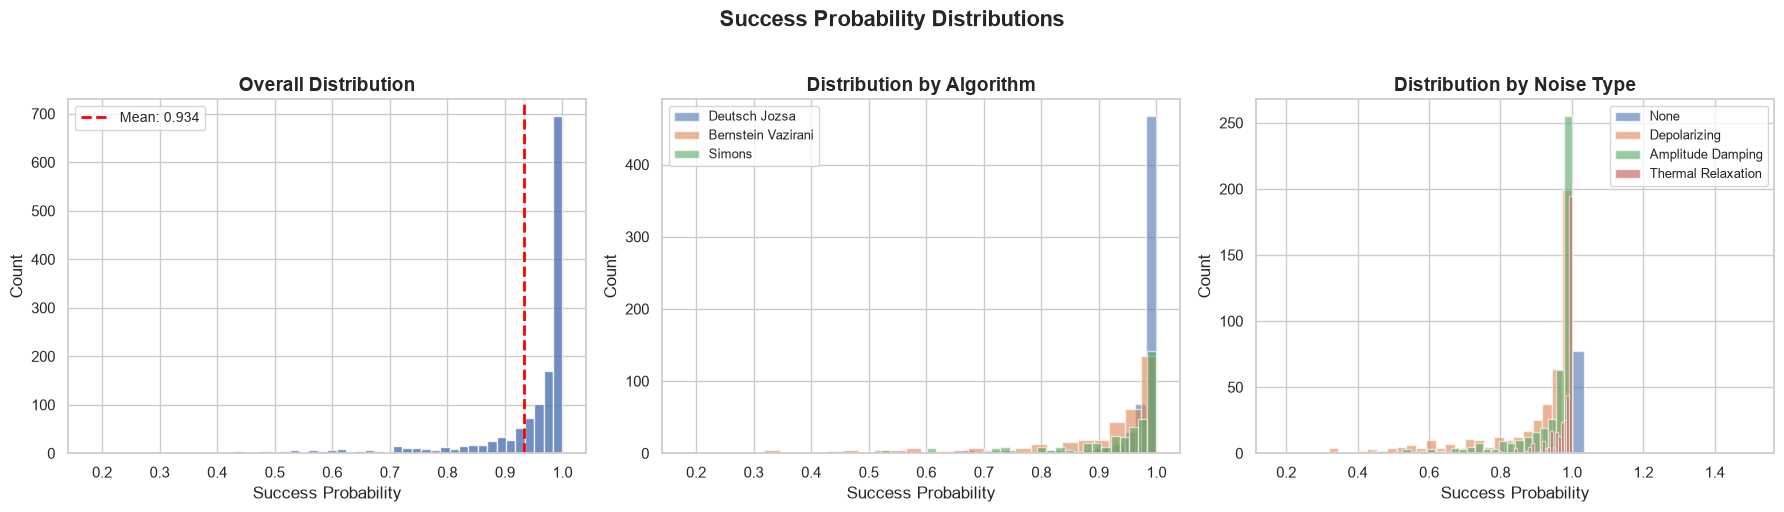

In [6]:
# Distribution of success probability
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Overall distribution
axes[0].hist(df['success_probability'], bins=50, color='#4C72B0', edgecolor='white',
             alpha=0.8)
axes[0].axvline(df['success_probability'].mean(), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {df["success_probability"].mean():.3f}')
axes[0].set_xlabel('Success Probability', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Overall Distribution', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)

# By algorithm
for algo in df['algorithm'].unique():
    subset = df[df['algorithm'] == algo]
    axes[1].hist(subset['success_probability'], bins=30, alpha=0.6,
                 label=algo.replace('_', ' ').title())
axes[1].set_xlabel('Success Probability', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Distribution by Algorithm', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=9)

# By noise type
for ntype in df['noise_type'].unique():
    subset = df[df['noise_type'] == ntype]
    axes[2].hist(subset['success_probability'], bins=30, alpha=0.6,
                 label=ntype.replace('_', ' ').title())
axes[2].set_xlabel('Success Probability', fontsize=12)
axes[2].set_ylabel('Count', fontsize=12)
axes[2].set_title('Distribution by Noise Type', fontsize=14, fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle('Success Probability Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/success_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.4 Correlation Analysis

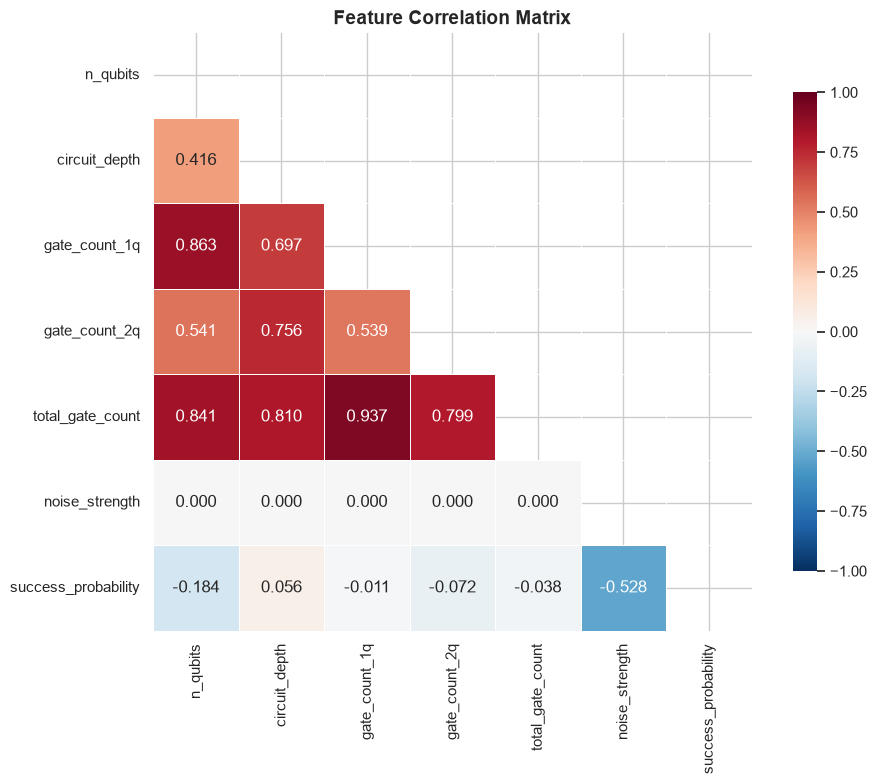


Correlation with success_probability:
success_probability    1.000000
circuit_depth          0.055535
gate_count_1q         -0.010884
total_gate_count      -0.037518
gate_count_2q         -0.071955
n_qubits              -0.184022
noise_strength        -0.527812


In [7]:
# Correlation heatmap of numeric features
numeric_cols = ['n_qubits', 'circuit_depth', 'gate_count_1q', 'gate_count_2q',
                'total_gate_count', 'noise_strength', 'success_probability']
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})

ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCorrelation with success_probability:')
print(corr_matrix['success_probability'].sort_values(ascending=False).to_string())

## 3.5 Key Trends

Let's visualize the most important relationships in the data.

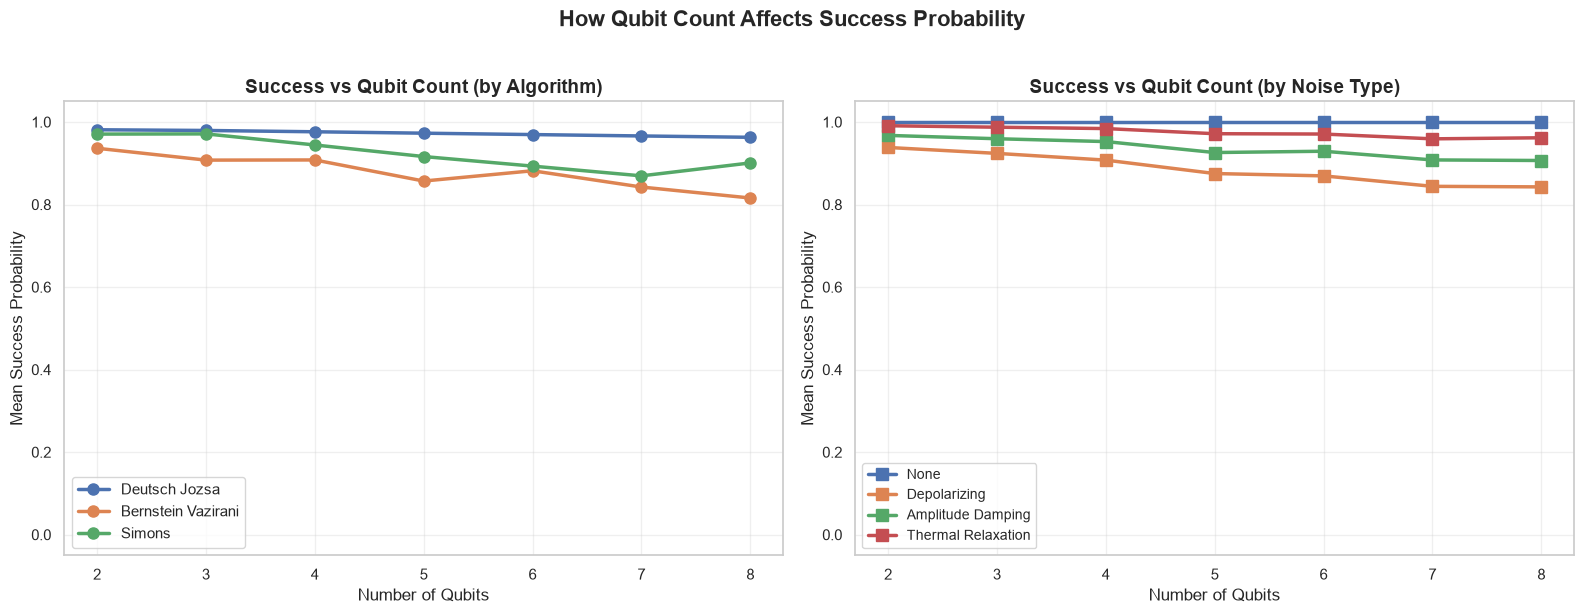

In [8]:
# Trend 1: Success probability vs Qubit Count by Algorithm
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# By algorithm
for algo in df['algorithm'].unique():
    subset = df[df['algorithm'] == algo]
    grouped = subset.groupby('n_qubits')['success_probability'].mean()
    label = algo.replace('_', ' ').title()
    axes[0].plot(grouped.index, grouped.values, marker='o', linewidth=2.5,
                 markersize=8, label=label)

axes[0].set_xlabel('Number of Qubits', fontsize=12)
axes[0].set_ylabel('Mean Success Probability', fontsize=12)
axes[0].set_title('Success vs Qubit Count (by Algorithm)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].set_ylim(-0.05, 1.05)
axes[0].grid(True, alpha=0.3)

# By noise type
for ntype in df['noise_type'].unique():
    subset = df[df['noise_type'] == ntype]
    grouped = subset.groupby('n_qubits')['success_probability'].mean()
    label = ntype.replace('_', ' ').title()
    axes[1].plot(grouped.index, grouped.values, marker='s', linewidth=2.5,
                 markersize=8, label=label)

axes[1].set_xlabel('Number of Qubits', fontsize=12)
axes[1].set_ylabel('Mean Success Probability', fontsize=12)
axes[1].set_title('Success vs Qubit Count (by Noise Type)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].set_ylim(-0.05, 1.05)
axes[1].grid(True, alpha=0.3)

plt.suptitle('How Qubit Count Affects Success Probability', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/success_vs_qubits.png', dpi=150, bbox_inches='tight')
plt.show()

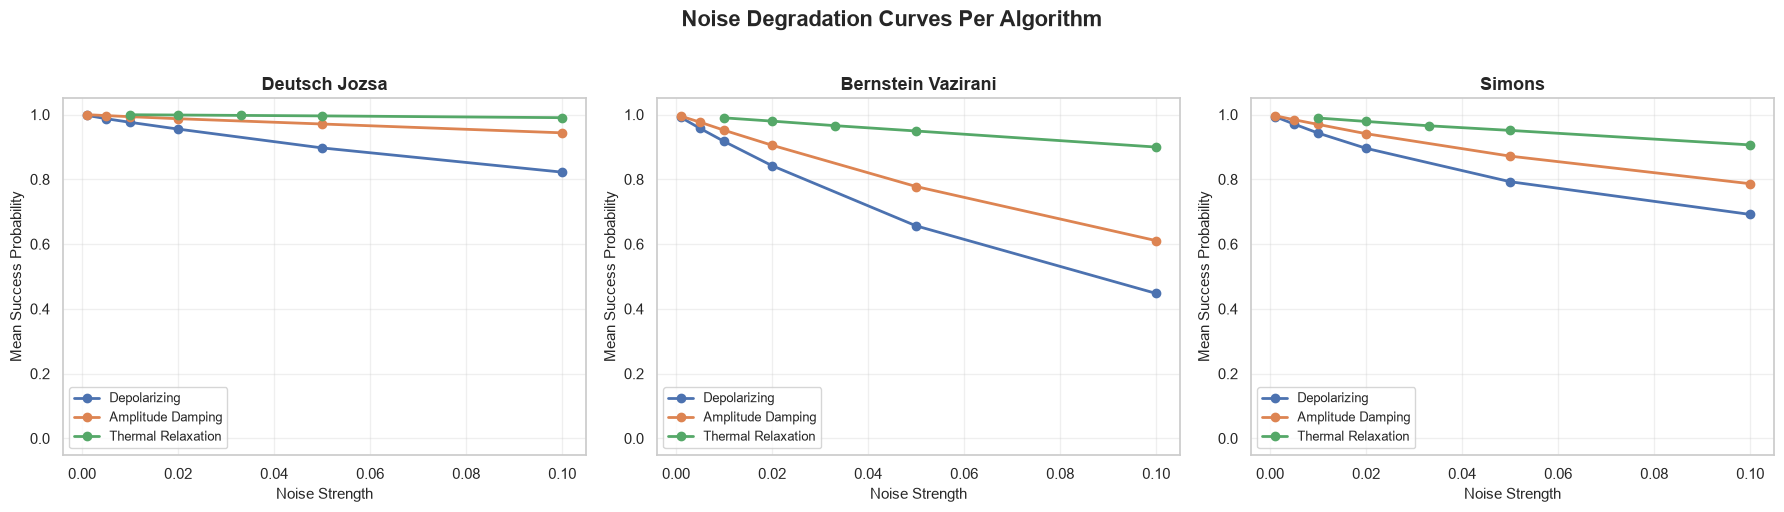

In [9]:
# Trend 2: Success vs Noise Strength — per algorithm, per noise type
df_noisy = df[df['noise_type'] != 'none']
algorithms = df_noisy['algorithm'].unique()

fig, axes = plt.subplots(1, len(algorithms), figsize=(6 * len(algorithms), 5))
if len(algorithms) == 1:
    axes = [axes]

for ax, algo in zip(axes, algorithms):
    subset = df_noisy[df_noisy['algorithm'] == algo]
    for ntype in subset['noise_type'].unique():
        nt_subset = subset[subset['noise_type'] == ntype]
        grouped = nt_subset.groupby('noise_strength')['success_probability'].mean()
        ax.plot(grouped.index, grouped.values, marker='o', linewidth=2,
                label=ntype.replace('_', ' ').title())

    ax.set_xlabel('Noise Strength', fontsize=11)
    ax.set_ylabel('Mean Success Probability', fontsize=11)
    ax.set_title(algo.replace('_', ' ').title(), fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)

plt.suptitle('Noise Degradation Curves Per Algorithm', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/noise_degradation_curves.png', dpi=150, bbox_inches='tight')
plt.show()

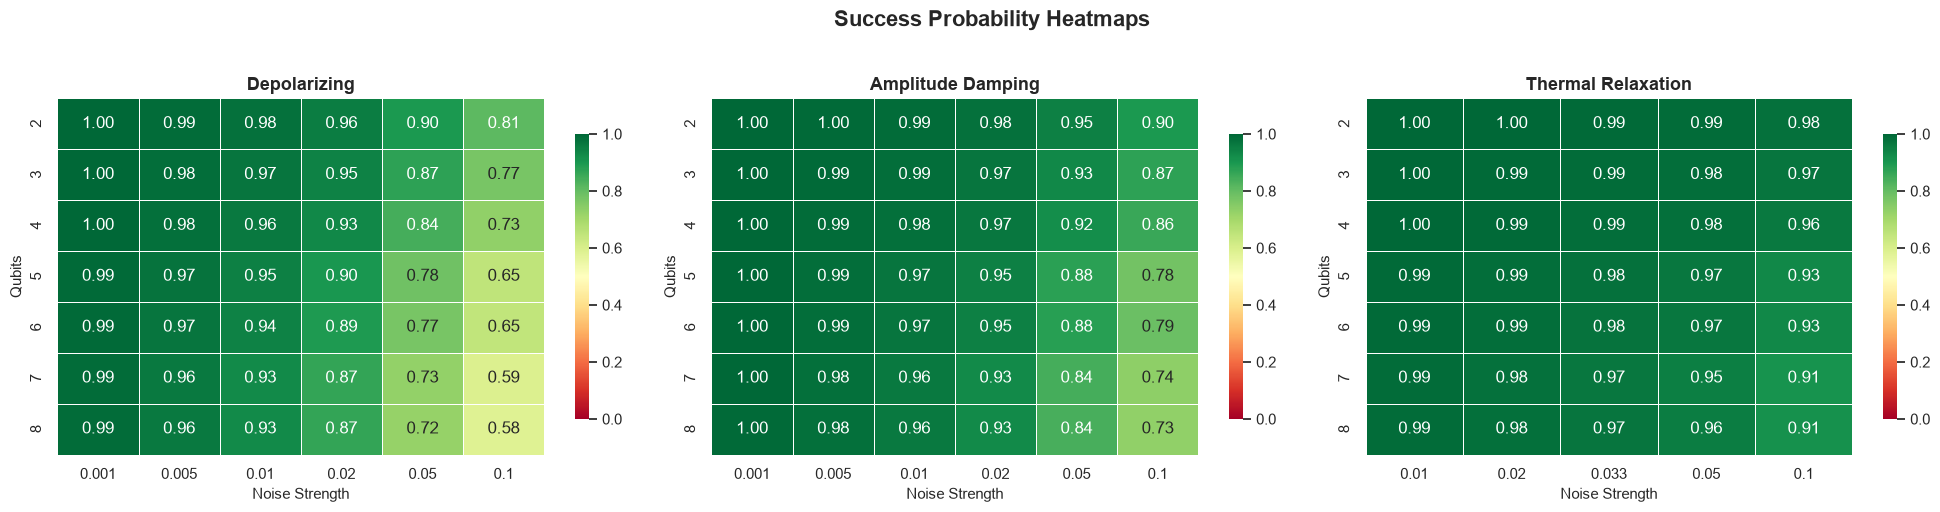

In [10]:
# Trend 3: Heatmap — Qubits x Noise Strength → Success Probability
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

noise_types = [nt for nt in df['noise_type'].unique() if nt != 'none']

for ax, ntype in zip(axes, noise_types):
    subset = df[df['noise_type'] == ntype]
    pivot = subset.pivot_table(
        values='success_probability',
        index='n_qubits',
        columns='noise_strength',
        aggfunc='mean'
    )
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn',
                vmin=0, vmax=1, ax=ax, linewidths=0.5,
                cbar_kws={'shrink': 0.8})
    ax.set_title(ntype.replace('_', ' ').title(), fontsize=13, fontweight='bold')
    ax.set_xlabel('Noise Strength', fontsize=11)
    ax.set_ylabel('Qubits', fontsize=11)

plt.suptitle('Success Probability Heatmaps', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/noise_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

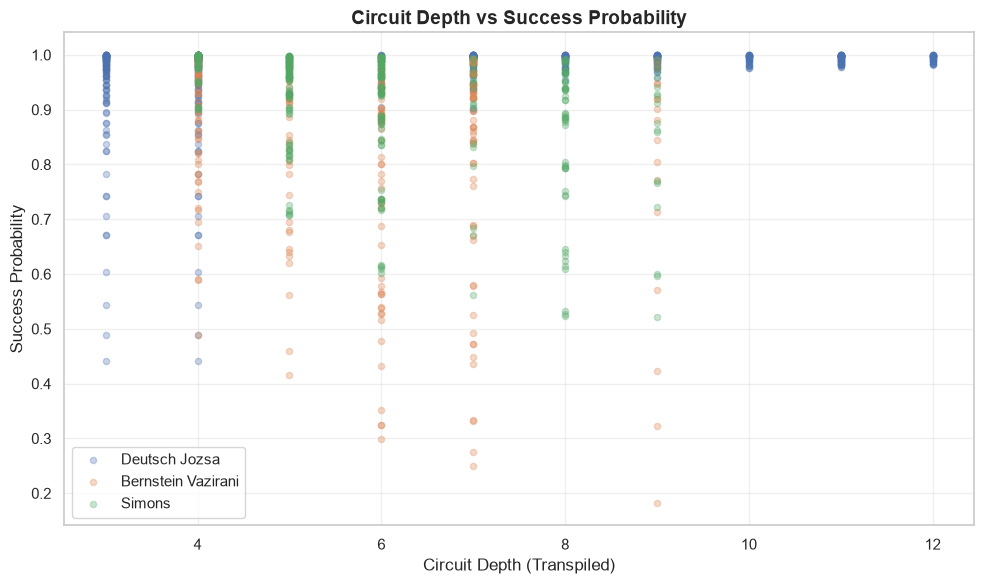

In [11]:
# Trend 4: Circuit Depth vs Success Probability (scatter)
fig, ax = plt.subplots(figsize=(10, 6))

for algo in df['algorithm'].unique():
    subset = df[(df['algorithm'] == algo) & (df['noise_type'] != 'none')]
    ax.scatter(subset['circuit_depth'], subset['success_probability'],
               alpha=0.3, s=20, label=algo.replace('_', ' ').title())

ax.set_xlabel('Circuit Depth (Transpiled)', fontsize=12)
ax.set_ylabel('Success Probability', fontsize=12)
ax.set_title('Circuit Depth vs Success Probability', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/depth_vs_success.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.6 Feature Engineering

Now we prepare the features for machine learning:
1. **One-hot encode** categorical columns (`algorithm`, `noise_type`)
2. **Drop** non-predictive columns (`oracle_desc`)
3. **Separate** features (X) from target (y = `success_probability`)

In [ ]:
# Encode features
X, y, feature_names = encode_features(df)

print(f'Feature matrix shape: {X.shape}')   
print(f'Target vector shape:  {y.shape}')
print(f'\nFeature names ({len(feature_names)}):')
for i, name in enumerate(feature_names):
    print(f'  {i+1}. {name}')

Feature matrix shape: (1386, 13)
Target vector shape:  (1386,)

Feature names (13):
  1. n_qubits
  2. circuit_depth
  3. gate_count_1q
  4. gate_count_2q
  5. total_gate_count
  6. noise_strength
  7. algo_bernstein_vazirani
  8. algo_deutsch_jozsa
  9. algo_simons
  10. noise_amplitude_damping
  11. noise_depolarizing
  12. noise_none
  13. noise_thermal_relaxation


In [13]:
# Preview the encoded feature matrix
X.head(10)

,n_qubits,circuit_depth,gate_count_1q,gate_count_2q,total_gate_count,noise_strength,algo_bernstein_vazirani,algo_deutsch_jozsa,algo_simons,noise_amplitude_damping,noise_depolarizing,noise_none,noise_thermal_relaxation
0,2,3,5,0,5,0.000,0,1,0,0,0,1,0
1,2,3,5,0,5,0.001,0,1,0,0,1,0,0
2,2,3,5,0,5,0.005,0,1,0,0,1,0,0
3,2,3,5,0,5,0.010,0,1,0,0,1,0,0
4,2,3,5,0,5,0.020,0,1,0,0,1,0,0
5,2,3,5,0,5,0.050,0,1,0,0,1,0,0
6,2,3,5,0,5,0.100,0,1,0,0,1,0,0
7,2,3,5,0,5,0.001,0,1,0,1,0,0,0
8,2,3,5,0,5,0.005,0,1,0,1,0,0,0
9,2,3,5,0,5,0.010,0,1,0,1,0,0,0
